In [67]:
import psi4
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
%load_ext autoreload
%autoreload 2
from src.lps_rscf import lps_solver

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
psi4.core.set_output_file('output.dat', False)
psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

atom_label, multip = 'He', 1
mol = psi4.geometry(f"0 {multip}\n {atom_label}\nsymmetry c1")

E, D, mu, iterations, e_list, e_conv, d_conv = lps_solver(
    mol=mol,
    E_conv=1.0e-5,
    D_conv=1.0e-5,
    maxiter=200,
    TP=['LDA_K_TF', 1.0],
    lam=1.0,
    EXC=['LDA_X', 1.0, 'LDA_C_VWN', 0.0],
    FA=[False, 1.0],
    damp=[0.9, 0.0, 0.0001],
    D_guess=None,
    DIIS=False,
    verbose=False
)
print('\nFinal SCF energy: %.4f Hartree' \
      ' in %.i iterations' % ( E, iterations))


Final SCF energy: -1.4775 Hartree in 76 iterations


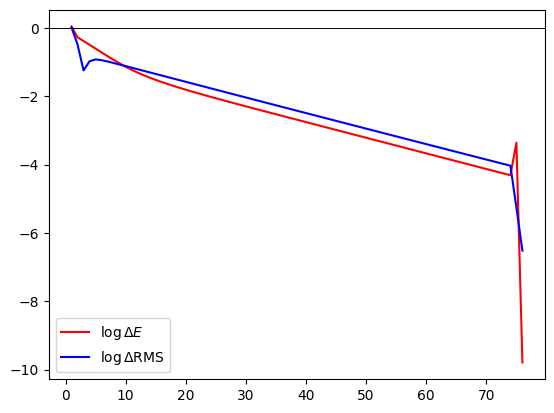

In [72]:
dist = np.linspace(1, iterations, iterations)
plt.plot(dist, e_conv, color = 'red', linestyle='-', label='$\\log{\\Delta E}$')
plt.plot(dist, d_conv, color = 'blue', linestyle='-', label='$\\log{\\Delta\\text{RMS}}$')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()

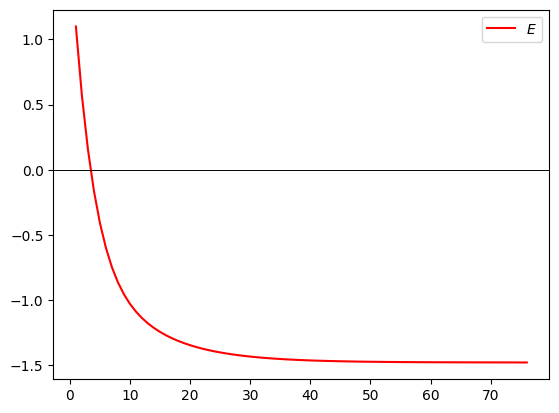

In [73]:
dist = np.linspace(1, iterations, iterations)
plt.plot(dist, e_list, color = 'red', linestyle='-', label='$E$')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()